# Getting track ID's for my personal songs

In [ ]:
import requests
import pandas as pd

In [ ]:
mySongs =[]

In [ ]:
url = 'https://track-analysis.p.rapidapi.com/pktx/analysis'

querystring = {'song':'thinkingabtu','artist':'saraunh0ly'}

headers = {
}

response = requests.get(url, headers=headers, params=querystring)
mySongs.append(response.json())
print(mySongs)

[{'id': '8c060d0e68d661cb4e66e5b02d79b1e6', 'key': 'E', 'mode': 'major', 'camelot': '12B', 'tempo': 105, 'duration': '6:07', 'popularity': 54, 'energy': 70, 'danceability': 75, 'happiness': 34, 'acousticness': 85, 'instrumentalness': 89, 'liveness': 10, 'speechiness': 5, 'loudness': '-10 dB'}, {'id': 'f31699816bd21d591b62052fde690293', 'key': 'C#', 'mode': 'major', 'camelot': '3B', 'tempo': 156, 'duration': '2:22', 'popularity': 53, 'energy': 99, 'danceability': 51, 'happiness': 84, 'acousticness': 23, 'instrumentalness': 83, 'liveness': 11, 'speechiness': 8, 'loudness': '-5 dB'}, {'message': 'You have exceeded the DAILY quota for Requests on your current plan, BASIC. Upgrade your plan at https://rapidapi.com/soundnet-soundnet-default/api/track-analysis'}]


In [ ]:
personalDataset = pd.DataFrame(mySongs)
personalDataset.to_csv('/content/drive/MyDrive/personal_spotify_data.csv', index=False)

# Data Preprocessing

#### Getting our data and importing libraries

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
filePath = '/content/drive/MyDrive/school classes/senior port/dataset.csv'
songDatasetog = pd.read_csv(filePath)
filePath2 = '/content/drive/MyDrive/school classes/senior port/personal_spotify_data.csv' 
personalDatasetog = pd.read_csv(filePath2)
## For my personal Data set.
# index 0 song: Magic Spells by Crystal Castles
# index 1 song: You Could Be The One by Snow Strippers
personalDataset = personalDatasetog
kaggleDataset = songDatasetog


#### Data info

In [53]:
kaggleDataset.info()
kaggleDataset.head(1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.143,0.0322,0.000001,0.358,0.715,87.917,4,acoustic


In [ ]:
personalDataset.info()
personalDataset.head()

,id,key,mode,camelot,tempo,duration,popularity,energy,danceability,happiness,acousticness,instrumentalness,liveness,speechiness,loudness
0,8c060d0e68d661cb4e66e5b02d79b1e6,E,major,12B,105,6:07,54,70,75,34,85,89,10,5,-10 dB
1,f31699816bd21d591b62052fde690293,C#,major,3B,156,2:22,53,99,51,84,23,83,11,8,-5 dB


#### Cleaning methods and feature engineering

In [4]:
def cleanPersonalsongs(df: pd.DataFrame) -> pd.DataFrame:
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns = ['Unnamed: 0'])
    
    df = df.drop(columns = ['key', 'mode', 'camelot'])

    df.insert(1, 'artists', ['Crystal Castles', 'Snow Strippers'])
    df.insert(2, 'track_name', ['Magic Spells', 'You Could Be The One'])
    
    df = df.rename(columns={'happiness' : 'valence'})

    #Change the scale on my personal songs
    cols_to_divide = ['energy', 'danceability', 'valence', 'acousticness', 'instrumentalness', 'liveness', 'speechiness']
    for cols in cols_to_divide:
        df[cols] = df[cols] / 100
    
    df['loudness'] = df['loudness'].str.replace(' dB', '')
    df['loudness'] = df['loudness'].astype(float)

    #Engineer feature high score means a lot of energy and not a lot of happiness
    df.insert(3, 'energy_valence_ratio', df['energy'] / (df['valence'] + 0.001) )
    
    return df

In [5]:
def cleanKaggleSongs(df: pd.DataFrame) -> pd.DataFrame:
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])

    df = df.dropna()

    df = df.drop(columns=['time_signature', 'mode', 'key'])

    #Engineer feature high score means a lot of energy and not a lot of happiness
    df.insert(5, 'energy_valence_ratio', df['energy'] / (df['valence'] + 0.001) )

    return df

#### Scaling our X

In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler

In [7]:
#Clean our data
dfPersonal = cleanPersonalsongs(personalDataset)
dfKaggle = cleanKaggleSongs(kaggleDataset)

In [8]:
scaler = StandardScaler()
features = ['energy_valence_ratio', 'tempo', 'popularity', 'energy', 'danceability', 'valence',
            'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'loudness']
#finds the mean and standard deviation of columns then shifts the data so the mean is 0 and 1 Standard Deviation equals 1.0
xKaggle = scaler.fit_transform(dfKaggle[features])
xPersonal = scaler.transform(dfPersonal[features])

# Dimensionality Reduction

### PCA

In [9]:
from sklearn.decomposition import PCA

In [10]:
#Have to fix dim
pca = PCA(n_components=0.90)
#Finds the main axis where data is spread and compresses onto those axis
xKagglePca = pca.fit_transform(xKaggle)
xPersonalPca = pca.transform(xPersonal)

### Autoencoder

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

In [12]:
class Autoencoder(nn.Module):

    def __init__(self, inputDim, latentDim):

        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(inputDim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, latentDim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latentDim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, inputDim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return latent, reconstructed

#### Variables

In [13]:
inputDim = xKaggle.shape[1]
latentDim = xKagglePca.shape[1]
model = Autoencoder(inputDim, latentDim)
crit = nn.MSELoss()
#pass the models weights into adam so he can update weights
opt = optim.Adam(model.parameters(), lr = 0.001)
tensorKaggle = torch.FloatTensor(xKaggle)

#### Training

In [14]:
epochs = 200
#reset adam to zero, get recon, calc mse, backprop, adjust weights do again
for i in range(epochs):
    opt.zero_grad()
    _ , reconstruction = model(tensorKaggle)
    loss = crit(reconstruction, tensorKaggle)
    loss.backward()
    opt.step()

In [15]:
#just get the latents without tracking gradients
with torch.no_grad():
    latentKaggleAE, _ = model(tensorKaggle)
    latentPerosnalAE, _ = model(torch.FloatTensor(xPersonal))

xKaggleAE = latentKaggleAE.numpy()
xPerosnalAE = latentPerosnalAE.numpy()

# Clustering & UMAP Visualization

In [16]:
from sklearn.cluster import KMeans
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

#### Silhouette scores

In [17]:
optimal_k = 5

# fit and predict clusters on the PCA latent space
kmeans_pca = KMeans(n_clusters=optimal_k, random_state=42)
clusters_pca = kmeans_pca.fit_predict(xKagglePca)

# fit and predict clusters on the Autoencoder latent space
kmeans_ae = KMeans(n_clusters=optimal_k, random_state=42)
clusters_ae = kmeans_ae.fit_predict(xKaggleAE)

In [18]:

# calculate for both to prove which is better
pca_score = silhouette_score(xKagglePca, clusters_pca)
ae_score = silhouette_score(xKaggleAE, clusters_ae)

print(f"PCA Silhouette Score: {pca_score}")
print(f"Autoencoder Silhouette Score: {ae_score}")

PCA Silhouette Score: 0.16681327353778194
Autoencoder Silhouette Score: 0.2777388393878937


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


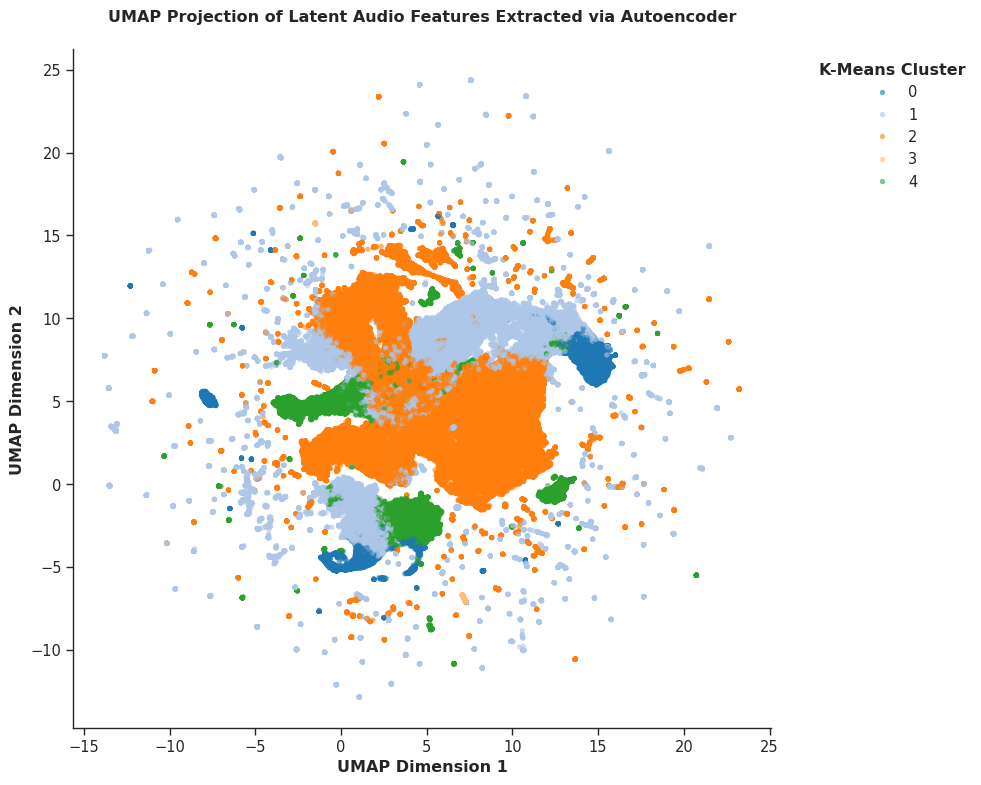

In [21]:
reducer = umap.UMAP(init='random', random_state=42)
embedding = reducer.fit_transform(xKaggleAE)

sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# Initialize figure
plt.figure(figsize=(10, 8))

# Create scatter plot with density adjustments
scatter = sns.scatterplot(
    x=embedding[:, 0], 
    y=embedding[:, 1], 
    hue=clusters_ae, 
    palette='tab20',    # Qualitative palette for categorical data
    s=12,               # Reduced point size
    alpha=0.6,          # Added transparency to reveal dense regions
    edgecolor=None,     # Removed borders to reduce visual clutter
    legend='full'
)

# Rigorous titling and axis labeling
plt.title('UMAP Projection of Latent Audio Features Extracted via Autoencoder', fontweight='bold', pad=20)
plt.xlabel('UMAP Dimension 1', fontweight='bold')
plt.ylabel('UMAP Dimension 2', fontweight='bold')

# Remove top and right borders for a cleaner aesthetic
sns.despine()

# Relocate the legend outside the primary plotting area
plt.legend(
    title='K-Means Cluster', 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    frameon=False,
    title_fontproperties={'weight': 'bold'}
)

# Ensure elements are not cut off when saving or displaying
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


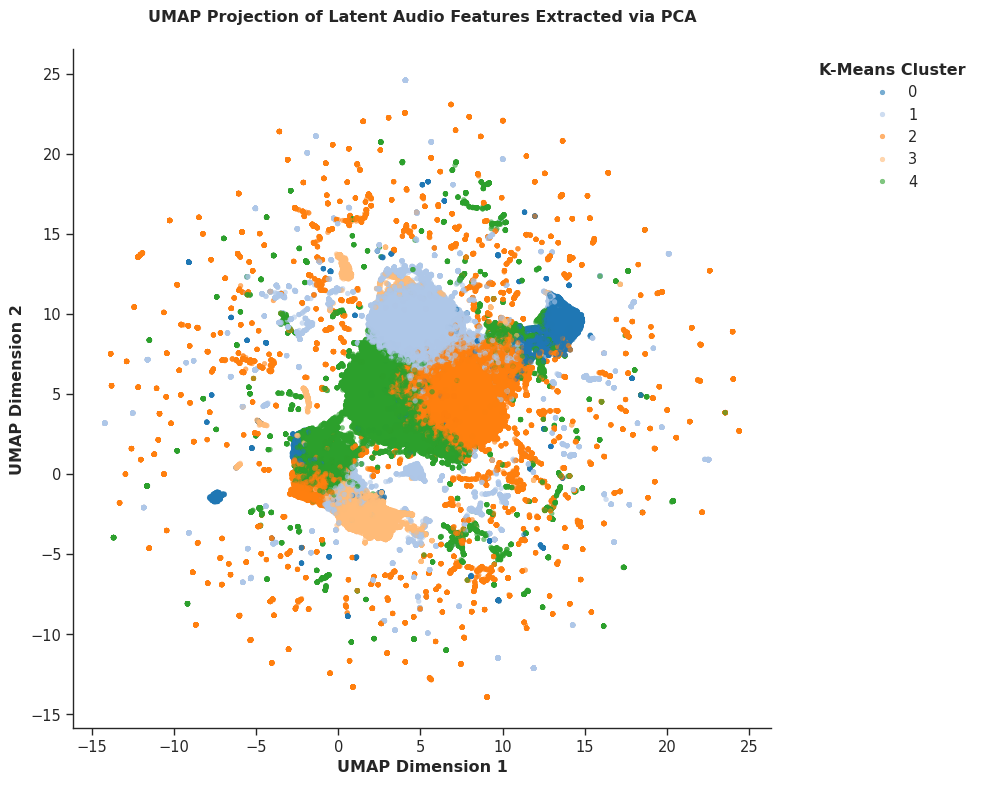

In [28]:
reducer = umap.UMAP(init='random', random_state=42)
embedding = reducer.fit_transform(xKagglePca)

sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# Initialize figure
plt.figure(figsize=(10, 8))

# Create scatter plot with density adjustments
scatter = sns.scatterplot(
    x=embedding[:, 0], 
    y=embedding[:, 1], 
    hue=clusters_pca, 
    palette='tab20',    # Qualitative palette for categorical data
    s=12,               # Reduced point size
    alpha=0.6,          # Added transparency to reveal dense regions
    edgecolor=None,     # Removed borders to reduce visual clutter
    legend='full'
)

# Rigorous titling and axis labeling
plt.title('UMAP Projection of Latent Audio Features Extracted via PCA', fontweight='bold', pad=20)
plt.xlabel('UMAP Dimension 1', fontweight='bold')
plt.ylabel('UMAP Dimension 2', fontweight='bold')

# Remove top and right borders for a cleaner aesthetic
sns.despine()

# Relocate the legend outside the primary plotting area
plt.legend(
    title='K-Means Cluster', 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    frameon=False,
    title_fontproperties={'weight': 'bold'}
)

# Ensure elements are not cut off when saving or displaying
plt.tight_layout()
plt.show()

# Centroid Creation & Recommendation Engine

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

In [26]:
personal_centroid = np.mean(xPerosnalAE, axis=0).reshape(1, -1)

# Calculate similarity between your centroid and the entire Kaggle latent space
similarities = cosine_similarity(personal_centroid, xKaggleAE).flatten()

# Add similarities back to the dataframe to view results
dfKaggle['similarity_score'] = similarities

# Filter out songs you already know/have, then grab the top recommendations
recommendations = dfKaggle.sort_values(by='similarity_score', ascending=False)
top_10_recs = recommendations[['track_name', 'artists', 'similarity_score']].head(10)

print(top_10_recs)

                                              track_name  \
13385                                         Morse Code   
24873                   Glaciär/For Minou - Original Mix   
10832                                      Winning Style   
54503                                        Hidden Love   
24645               Evangelion - Jonson & Siminski Remix   
13325   Percolator - Claude VonStroke Must Have Subs Mix   
54615                                            Modul 1   
24920                                           In Limbo   
13020            Work.Groove - Chezz Cosmic Groove Remix   
111426                                 I Feel the Weight   

                                  artists  similarity_score  
13385                             Armando          0.999082  
24873                         Aril Brikha          0.998793  
10832                      Propellerheads          0.998749  
54503                              Mokhov          0.998692  
24645                        

# JUNK

Calculating optimal k. This may take a few minutes...


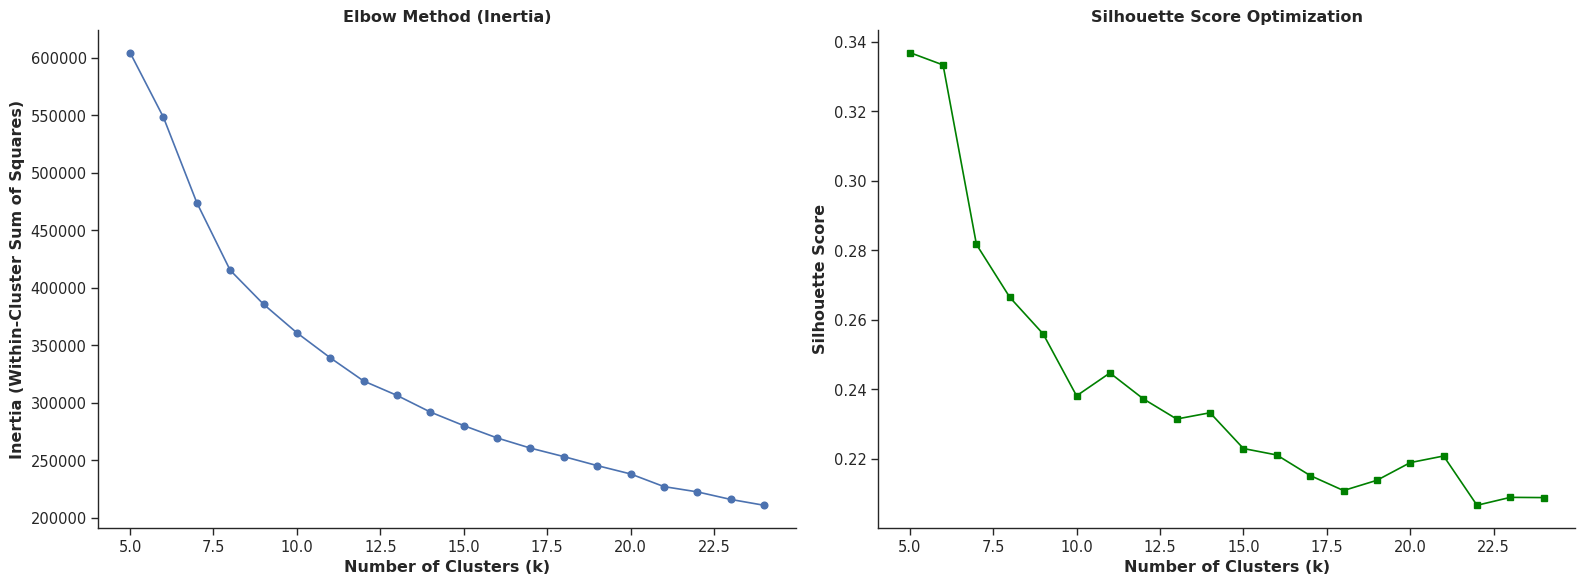

In [19]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Initialize lists to store the results
inertia_values = []
silhouette_scores = []

# Define the range of clusters to test (testing 5 to 24 genres)
K_range = range(5, 25) 

print("Calculating optimal k. This may take a few minutes...")

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(xKaggleAE)
    
    # Calculate Inertia (for the Elbow Method)
    inertia_values.append(kmeans.inertia_)
    
    # Calculate Silhouette Score
    score = silhouette_score(xKaggleAE, cluster_labels)
    silhouette_scores.append(score)

# Plotting the results side-by-side for your presentation
import seaborn as sns
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Elbow Plot
ax1.plot(K_range, inertia_values, marker='o')
ax1.set_title('Elbow Method (Inertia)', fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)', fontweight='bold')
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontweight='bold')
sns.despine(ax=ax1)

# Subplot 2: Silhouette Plot
ax2.plot(K_range, silhouette_scores, marker='s', color='green')
ax2.set_title('Silhouette Score Optimization', fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)', fontweight='bold')
ax2.set_ylabel('Silhouette Score', fontweight='bold')
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()